# Analisis IPM Provinsi Indonesia
### UMAP + GMM Clustering | Fixed Effect Panel Regression | SHAP | XGBoost Forecasting | Choropleth

**Catatan metodologis:**
- `rls` dan `hls` dikeluarkan dari semua model, keduanya sub-indeks langsung IPM (tautologis).
- Variabel duplikat semester (tpt_agt, tpak_agt, gk_sept, pct_miskin_sept) dikeluarkan karena multikolinear tinggi.
- TimeSeriesSplit digunakan untuk CV agar tidak ada leakage antar waktu.
- UMAP di-fit hanya pada cross-section 2024.
- Forecasting: OLS trend per provinsi + damping slope, prediksi IPM via XGBoost global.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    r2_score, mean_absolute_error, mean_squared_error
)
from sklearn.model_selection import TimeSeriesSplit
import umap
import shap
from xgboost import XGBRegressor
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
import json
import pickle

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED', '#0891B2']
print('Library OK.')


Library OK.


## 1. Load & Preprocessing

In [ ]:
df = pd.read_csv('data_bps_provinsi.csv')
df.columns = [
    'provinsi','tahun','aps_1315','aps_1618','aps_1924',
    'tpt_feb','tpt_agt','tpak_feb','tpak_agt',
    'gk_maret','gk_sept','miskin_maret','miskin_sept',
    'pct_miskin_maret','pct_miskin_sept','ipm','rls','hls'
]
for col in df.columns[2:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# rls/hls dikeluarkan: sub-indeks langsung IPM -> tautologis
# duplikat semester dikeluarkan: berkorelasi sangat tinggi
FEATURES = ['aps_1315','aps_1618','aps_1924','tpt_feb','tpak_feb','gk_maret','pct_miskin_maret']
FEATURE_LABELS = {
    'aps_1315':'APS 13-15 Thn','aps_1618':'APS 16-18 Thn','aps_1924':'APS 19-24 Thn',
    'tpt_feb':'TPT Februari','tpak_feb':'TPAK Februari',
    'gk_maret':'Garis Kemiskinan','pct_miskin_maret':'% Penduduk Miskin'
}
VAR_LABELS = FEATURE_LABELS.copy()

print(f'Shape          : {df.shape}')
print(f'Tahun          : {sorted(df["tahun"].unique())}')
print(f'Provinsi       : {df["provinsi"].nunique()}')
missing = df[FEATURES+['ipm']].isnull().sum()
print(f'Missing values : {missing[missing>0].to_dict() if missing.sum()>0 else "Tidak ada"}')
df[FEATURES+['ipm']].describe().round(2)

Shape          : (151, 18)
Tahun          : [2021, 2022, 2023, 2024]
Provinsi       : 38
Missing values : Tidak ada


,aps_1315,aps_1618,aps_1924,tpt_feb,tpak_feb,gk_maret,pct_miskin_maret,ipm
count,151.00,151.00,151.00,151.00,151.00,151.00,151.00,151.00
mean,94.39,74.57,27.62,4.95,69.49,583860.29,11.70,72.26
std,5.11,6.39,6.13,1.52,4.03,123126.10,6.77,4.74
min,80.02,63.98,17.59,3.04,61.97,364251.00,4.00,61.40
25%,93.27,69.91,23.74,3.73,66.50,490047.00,6.46,70.47
50%,95.93,74.07,26.42,4.53,69.36,570368.00,10.47,72.96
75%,97.62,79.28,30.74,5.78,71.72,663415.50,14.60,74.65
max,99.43,91.17,51.60,10.12,80.23,1007060.00,32.97,83.55


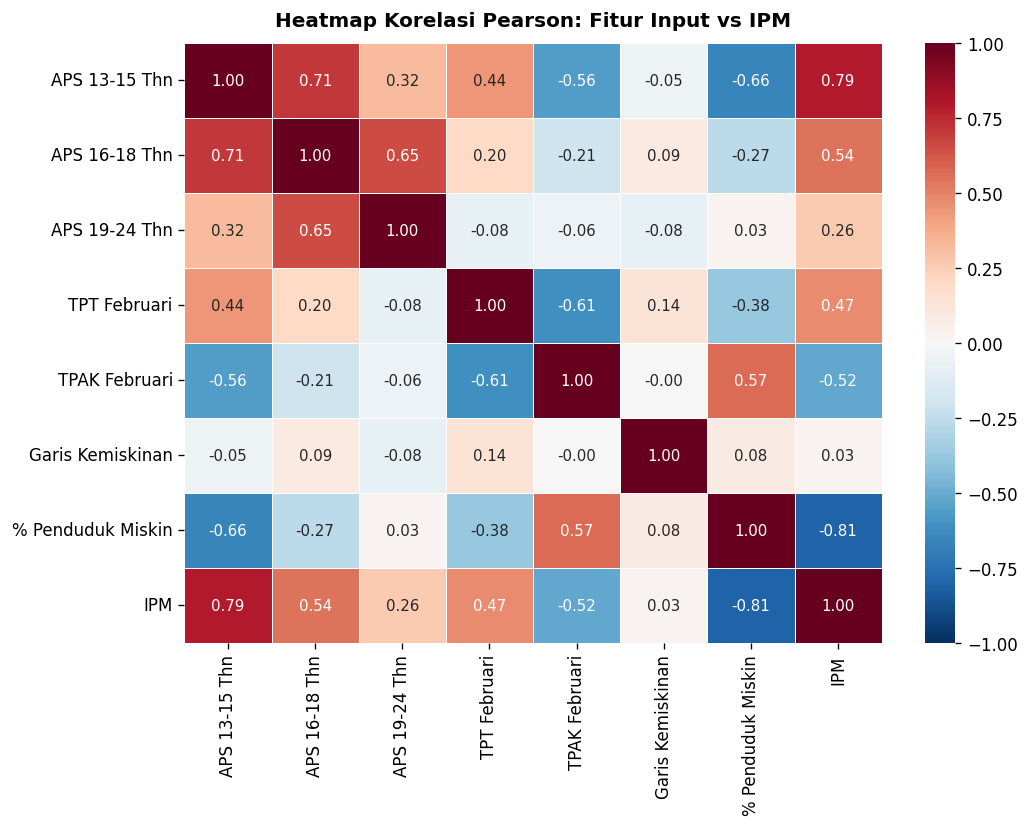

Korelasi dengan IPM (diurutkan |r|):
  % Penduduk Miskin         : r = -0.810  (negatif)
  APS 13-15 Thn             : r =  0.790  (positif)
  APS 16-18 Thn             : r =  0.540  (positif)
  TPAK Februari             : r = -0.520  (negatif)
  TPT Februari              : r =  0.470  (positif)
  APS 19-24 Thn             : r =  0.260  (positif)
  Garis Kemiskinan          : r =  0.030  (positif)


In [4]:
corr = df[FEATURES+['ipm']].corr().round(2)
rename_map = {f: FEATURE_LABELS[f] for f in FEATURES}; rename_map['ipm'] = 'IPM'
corr_d = corr.rename(index=rename_map, columns=rename_map)

fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr_d, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size':9})
ax.set_title('Heatmap Korelasi Pearson: Fitur Input vs IPM', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('plot_korelasi.png', bbox_inches='tight')
plt.show()

print('Korelasi dengan IPM (diurutkan |r|):')
corr_ipm = corr['ipm'].drop('ipm').sort_values(key=abs, ascending=False)
for feat, val in corr_ipm.items():
    print(f'  {FEATURE_LABELS[feat]:<26}: r = {val:>6.3f}  ({"positif" if val>0 else "negatif"})')

In [5]:
df_latest = df[df['tahun']==2024].copy().reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_latest[FEATURES].astype(float))

assert not np.isnan(X_scaled).any()

print(f'Data 2024: {df_latest.shape[0]} provinsi, {X_scaled.shape[1]} fitur. Tidak ada NaN.')

print("\nDaftar fitur yang digunakan:")
print(FEATURES)

import pandas as pd
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)

print("\nPreview data setelah scaling:")
print(X_scaled_df.head())

print("\nCek mean & std:")
print(X_scaled_df.describe().loc[['mean','std']])

Data 2024: 38 provinsi, 7 fitur. Tidak ada NaN.

Daftar fitur yang digunakan:
['aps_1315', 'aps_1618', 'aps_1924', 'tpt_feb', 'tpak_feb', 'gk_maret', 'pct_miskin_maret']

Preview data setelah scaling:
   aps_1315  aps_1618  aps_1924   tpt_feb  tpak_feb  gk_maret  \
0  0.643741  1.333860  0.842460  0.737241 -1.145490  0.132215   
1  0.454814  0.694339  0.101147  0.371919  0.245558 -0.009916   
2  0.460718  1.475292  1.664674  0.844688  0.083099  0.488896   
3  0.283598  0.525234  0.342198 -0.337234 -1.130260  0.404845   
4  0.307214 -0.349495 -0.663280 -0.158155 -0.444889  0.048224   

   pct_miskin_maret  
0          0.463292  
1         -0.474044  
2         -0.777477  
3         -0.672327  
4         -0.607735  

Cek mean & std:
          aps_1315      aps_1618      aps_1924       tpt_feb      tpak_feb  \
mean  1.402387e-15 -8.764919e-16 -4.966787e-16 -8.589620e-16 -3.318983e-15   
std   1.013423e+00  1.013423e+00  1.013423e+00  1.013423e+00  1.013423e+00   

          gk_maret  pct_

## 2. UMAP Dimensionality Reduction

In [6]:
reducer  = umap.UMAP(n_components=2, n_neighbors=5, min_dist=0.05,
                      metric='euclidean', random_state=42)
embedding = reducer.fit_transform(X_scaled)
df_latest['umap_1'] = embedding[:,0]
df_latest['umap_2'] = embedding[:,1]

var_emb   = np.var(embedding, axis=0)
var_share = var_emb / var_emb.sum()
print(f'Embedding shape     : {embedding.shape}')
print(f'Range dim-1         : [{embedding[:,0].min():.3f}, {embedding[:,0].max():.3f}]')
print(f'Range dim-2         : [{embedding[:,1].min():.3f}, {embedding[:,1].max():.3f}]')
print(f'Proporsi variansi   : dim-1={var_share[0]:.3f}, dim-2={var_share[1]:.3f}')

Embedding shape     : (38, 2)
Range dim-1         : [0.559, 7.089]
Range dim-2         : [11.185, 17.067]
Proporsi variansi   : dim-1=0.474, dim-2=0.526


## 3. GMM Clustering

In [7]:
bic_scores, aic_scores, sil_scores, db_scores = [], [], [], []
k_range = range(2, 8)

for k in k_range:
    g   = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=10)
    g.fit(embedding)
    lbl = g.predict(embedding)
    bic_scores.append(g.bic(embedding))
    aic_scores.append(g.aic(embedding))
    sil_scores.append(silhouette_score(embedding, lbl))
    db_scores.append(davies_bouldin_score(embedding, lbl))

optimal_k = list(k_range)[np.argmin(bic_scores)]

print('GMM Model Selection:')
print(f'{"K":>3} | {"BIC":>10} | {"AIC":>10} | {"Silhouette":>11} | {"DB Index":>9}')
print('-'*55)
for k,b,a,s,d in zip(k_range,bic_scores,aic_scores,sil_scores,db_scores):
    tag = '  <- optimal' if k==optimal_k else ''
    print(f'{k:>3} | {b:>10.2f} | {a:>10.2f} | {s:>11.4f} | {d:>9.4f}{tag}')
print(f'\nOptimal K = {optimal_k}')

GMM Model Selection:
  K |        BIC |        AIC |  Silhouette |  DB Index
-------------------------------------------------------
  2 |     268.07 |     250.05 |      0.4891 |    0.6355  <- optimal
  3 |     269.75 |     241.91 |      0.4497 |    0.7479
  4 |     276.68 |     239.02 |      0.3873 |    0.8547
  5 |     278.17 |     230.68 |      0.4638 |    0.7161
  6 |     278.65 |     221.34 |      0.4737 |    0.5746
  7 |     280.14 |     213.00 |      0.4645 |    0.5710

Optimal K = 2


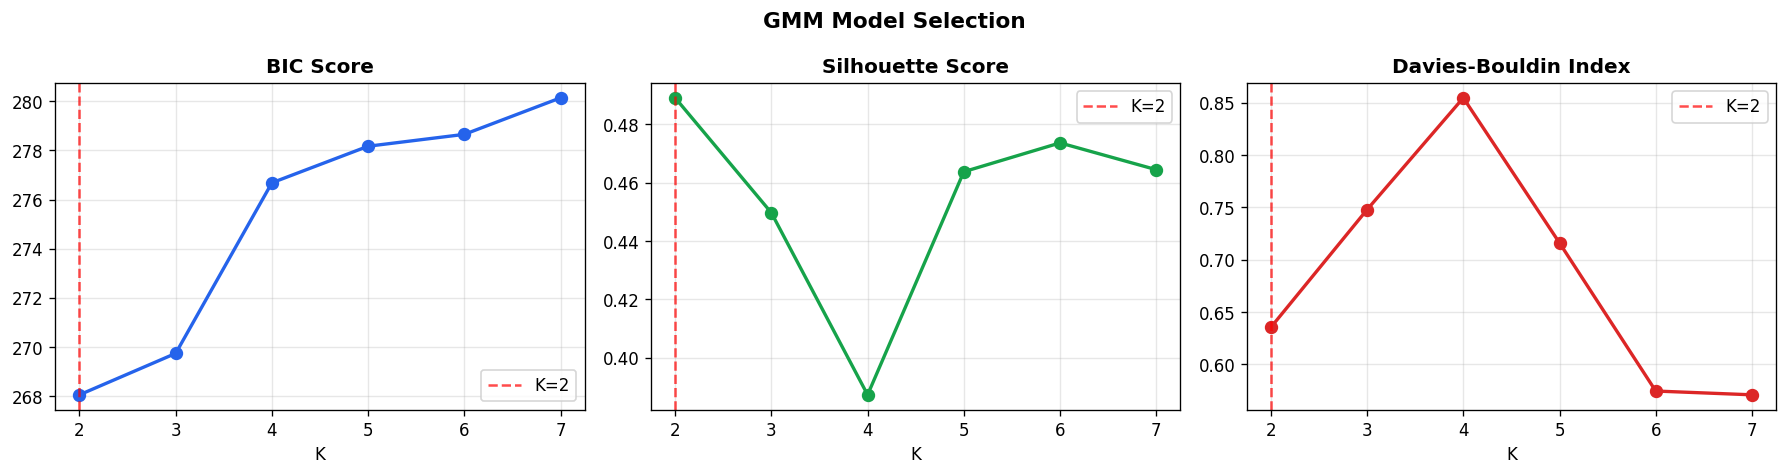

In [8]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax, y, lbl, c in zip(axes,
    [bic_scores, sil_scores, db_scores],
    ['BIC Score','Silhouette Score','Davies-Bouldin Index'],
    PALETTE):
    ax.plot(list(k_range), y, 'o-', color=c, linewidth=2, markersize=7)
    ax.axvline(optimal_k, color='red', linestyle='--', alpha=0.7, label=f'K={optimal_k}')
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel('K')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('GMM Model Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_gmm_selection.png', bbox_inches='tight')
plt.show()

In [9]:
gmm_final    = GaussianMixture(n_components=optimal_k, covariance_type='full',
                                random_state=42, n_init=20)
gmm_final.fit(embedding)
labels        = gmm_final.predict(embedding)
proba_matrix  = gmm_final.predict_proba(embedding)
df_latest['cluster']            = labels
df_latest['cluster_confidence'] = proba_matrix.max(axis=1)

sil_final = silhouette_score(embedding, labels)
db_final  = davies_bouldin_score(embedding, labels)
ch_final  = calinski_harabasz_score(embedding, labels)

print(f'Evaluasi GMM Final (K={optimal_k}):')
print(f'  Silhouette Score     : {sil_final:.4f}')
print(f'  Davies-Bouldin Index : {db_final:.4f}')
print(f'  Calinski-Harabasz    : {ch_final:.4f}')
print(f'  Confidence mean      : {proba_matrix.max(axis=1).mean():.4f}')
print(f'  Confidence min       : {proba_matrix.max(axis=1).min():.4f}')
print()
print('Distribusi cluster:')
print(df_latest['cluster'].value_counts().sort_index().rename('n_provinsi').to_string())

Evaluasi GMM Final (K=2):
  Silhouette Score     : 0.4891
  Davies-Bouldin Index : 0.6355
  Calinski-Harabasz    : 54.1752
  Confidence mean      : 0.9796
  Confidence min       : 0.8156

Distribusi cluster:
cluster
0    12
1    26


In [10]:
# Cluster diurutkan berdasarkan rata-rata IPM (Cluster A = IPM terendah)
# Penamaan semantik diserahkan kepada peneliti setelah membaca profil di bawah
mean_ipm_cl  = df_latest.groupby('cluster')['ipm'].mean().sort_values()
rank_map     = {orig_c: rank for rank, orig_c in enumerate(mean_ipm_cl.index)}
df_latest['cluster_id']    = df_latest['cluster'].map(rank_map)
id_to_letter = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F'}
df_latest['cluster_label'] = df_latest['cluster_id'].map(
    lambda i: f'Cluster {id_to_letter.get(i, str(i))}')

cluster_map    = dict(zip(df_latest['provinsi'], df_latest['cluster_id']))
clusterlbl_map = dict(zip(df_latest['provinsi'], df_latest['cluster_label']))
df['cluster_id']    = df['provinsi'].map(cluster_map)
df['cluster_label'] = df['provinsi'].map(clusterlbl_map)

print('='*72)
print('PROFIL CLUSTER (rata-rata dan std per variabel kunci)')
print('='*72)
profile_cols = ['ipm','aps_1315','aps_1618','aps_1924','tpt_feb','tpak_feb',
                'gk_maret','pct_miskin_maret']
col_rename = {
    'ipm':'IPM','aps_1315':'APS 13-15','aps_1618':'APS 16-18',
    'aps_1924':'APS 19-24','tpt_feb':'TPT Feb','tpak_feb':'TPAK Feb',
    'gk_maret':'Garis Kemiskinan','pct_miskin_maret':'% Miskin'
}
profile = df_latest.groupby('cluster_label')[profile_cols].mean().round(2).rename(columns=col_rename)
print(profile.to_string())

print()
print('='*72)
print('ANGGOTA TIAP CLUSTER')
print('='*72)
for cl_lbl in sorted(df_latest['cluster_label'].unique()):
    sub     = df_latest[df_latest['cluster_label']==cl_lbl].sort_values('ipm', ascending=False)
    avg_ipm = sub['ipm'].mean()
    avg_m   = sub['pct_miskin_maret'].mean()
    conf    = sub['cluster_confidence'].mean()
    print(f'\n{cl_lbl}  |  n={len(sub)}  |  mean IPM={avg_ipm:.2f}  '
          f'|  mean % miskin={avg_m:.2f}%  |  mean conf={conf:.4f}')
    print(f'{"Provinsi":<30} {"IPM":>6} {"% Miskin":>9} {"TPT Feb":>8} {"TPAK Feb":>9} {"Conf":>7}')
    print('-'*70)
    for _, row in sub.iterrows():
        print(f'{row["provinsi"]:<30} {row["ipm"]:>6.2f} {row["pct_miskin_maret"]:>9.2f} '
              f'{row["tpt_feb"]:>8.2f} {row["tpak_feb"]:>9.2f} {row["cluster_confidence"]:>7.4f}')

PROFIL CLUSTER (rata-rata dan std per variabel kunci)
                 IPM  APS 13-15  APS 16-18  APS 19-24  TPT Feb  TPAK Feb  Garis Kemiskinan  % Miskin
cluster_label                                                                                       
Cluster A      69.23      90.15      72.37      27.57     3.42     73.22         604881.67     16.35
Cluster B      74.38      96.43      75.82      28.20     5.32     67.97         661667.15      8.75

ANGGOTA TIAP CLUSTER

Cluster A  |  n=12  |  mean IPM=69.23  |  mean % miskin=16.35%  |  mean conf=0.9508
Provinsi                          IPM  % Miskin  TPT Feb  TPAK Feb    Conf
----------------------------------------------------------------------
BALI                            78.01      4.00     3.73     77.19  0.9012
BENGKULU                        74.30     13.56     3.21     72.72  0.8777
SULAWESI TENGGARA               72.94     11.21     3.66     67.55  0.9673
NUSA TENGGARA BARAT             72.37     12.91     3.73     71.

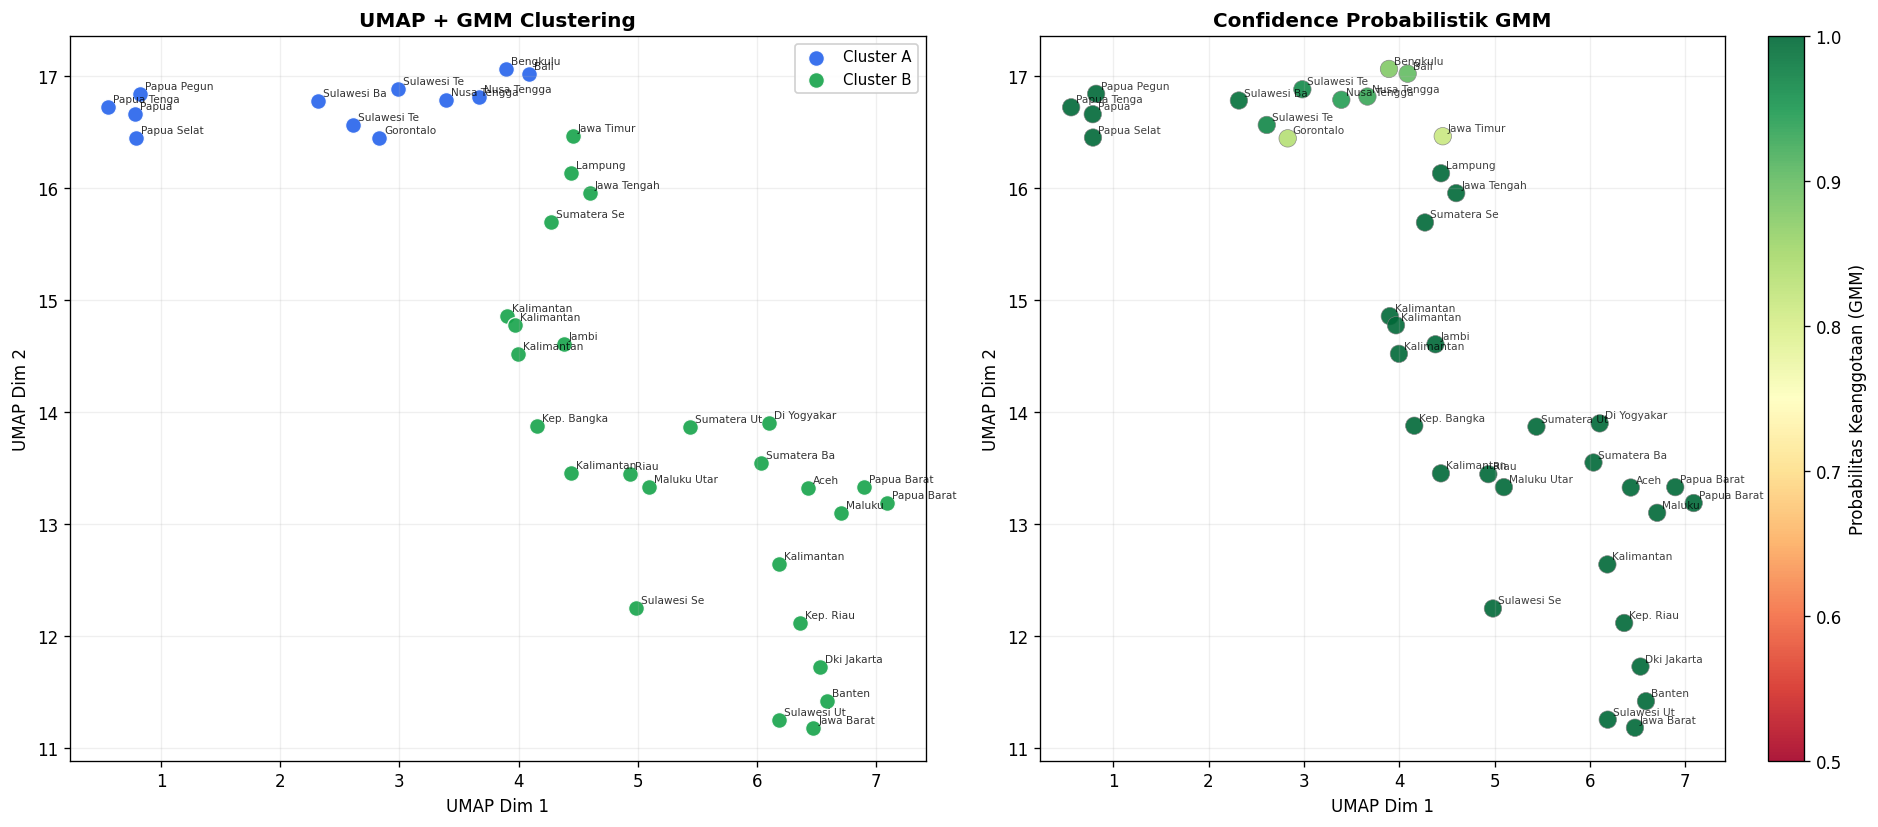

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16,7))

for cl_id in sorted(df_latest['cluster_id'].unique()):
    mask = df_latest['cluster_id']==cl_id
    lbl  = df_latest.loc[mask,'cluster_label'].iloc[0]
    axes[0].scatter(df_latest.loc[mask,'umap_1'], df_latest.loc[mask,'umap_2'],
                    c=PALETTE[cl_id], label=lbl, s=90, alpha=0.9,
                    edgecolors='white', linewidth=0.8)

for _, row in df_latest.iterrows():
    axes[0].annotate(row['provinsi'].title()[:11], (row['umap_1'],row['umap_2']),
                     fontsize=6.3, alpha=0.8, xytext=(3,3), textcoords='offset points')
axes[0].set_title('UMAP + GMM Clustering', fontsize=12, fontweight='bold')
axes[0].set_xlabel('UMAP Dim 1'); axes[0].set_ylabel('UMAP Dim 2')
axes[0].legend(fontsize=9, framealpha=0.9); axes[0].grid(alpha=0.2)

sc = axes[1].scatter(df_latest['umap_1'], df_latest['umap_2'],
                      c=df_latest['cluster_confidence'], cmap='RdYlGn',
                      s=110, alpha=0.9, edgecolors='gray', linewidth=0.4,
                      vmin=0.5, vmax=1.0)
plt.colorbar(sc, ax=axes[1], label='Probabilitas Keanggotaan (GMM)')
for _, row in df_latest.iterrows():
    axes[1].annotate(row['provinsi'].title()[:11], (row['umap_1'],row['umap_2']),
                     fontsize=6.3, alpha=0.75, xytext=(3,3), textcoords='offset points')
axes[1].set_title('Confidence Probabilistik GMM', fontsize=12, fontweight='bold')
axes[1].set_xlabel('UMAP Dim 1'); axes[1].set_ylabel('UMAP Dim 2'); axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('plot_umap_clustering.png', bbox_inches='tight')
plt.show()

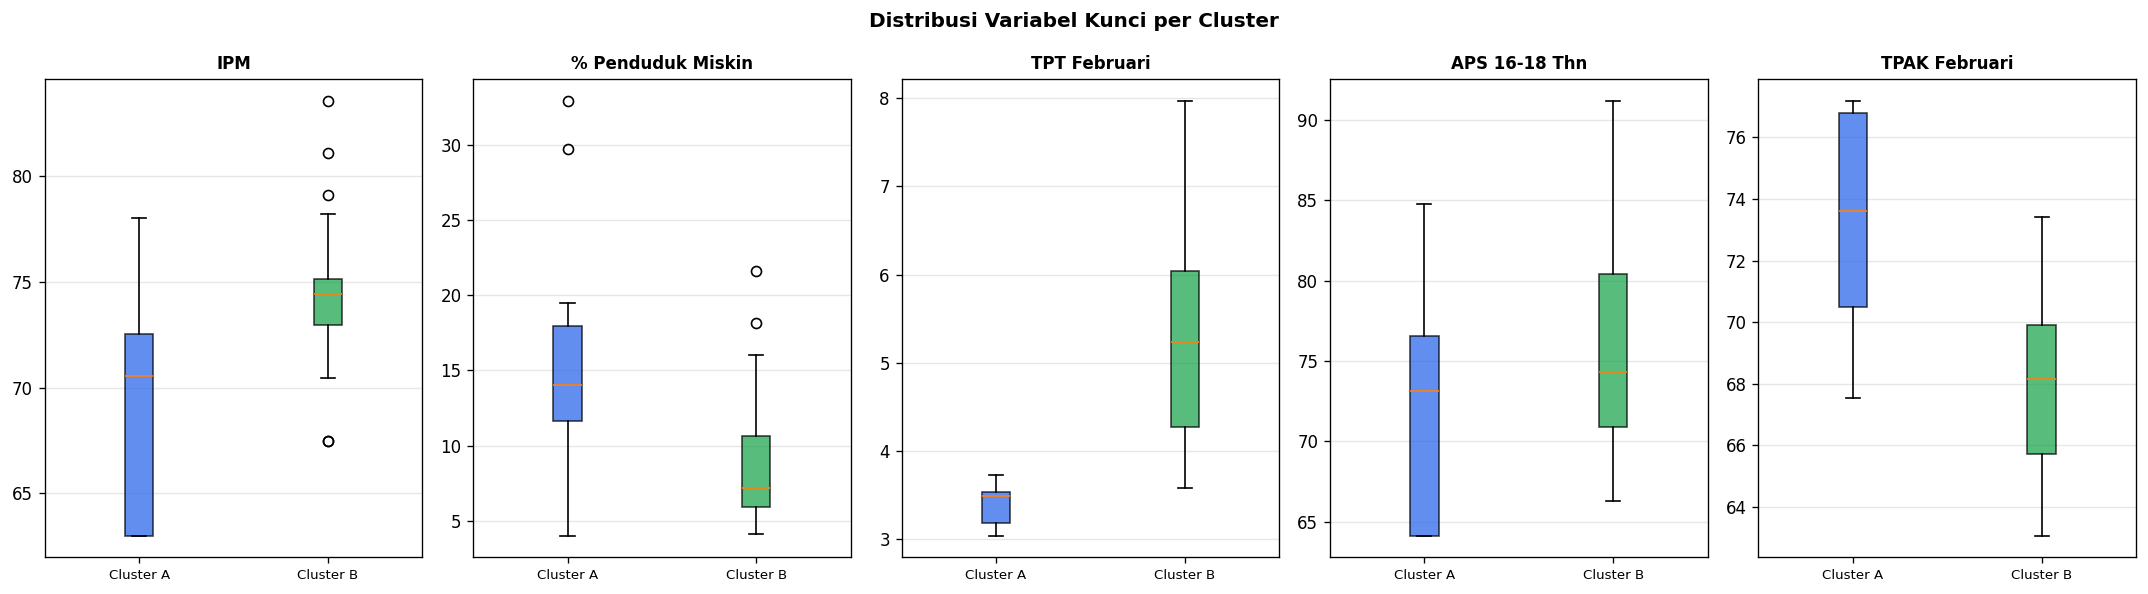

In [11]:
# Boxplot distribusi variabel kunci per cluster
vars_bp  = ['ipm','pct_miskin_maret','tpt_feb','aps_1618','tpak_feb']
names_bp = ['IPM','% Penduduk Miskin','TPT Februari','APS 16-18 Thn','TPAK Februari']
fig, axes = plt.subplots(1, len(vars_bp), figsize=(18,5))

for ax, var, vname in zip(axes, vars_bp, names_bp):
    cl_ids = sorted(df_latest['cluster_id'].unique())
    data_per_cl = [df_latest[df_latest['cluster_id']==i][var].values for i in cl_ids]
    lbls_bp     = [df_latest[df_latest['cluster_id']==i]['cluster_label'].iloc[0] for i in cl_ids]
    bp = ax.boxplot(data_per_cl, patch_artist=True)
    for patch, color in zip(bp['boxes'], PALETTE[:optimal_k]):
        patch.set_facecolor(color); patch.set_alpha(0.72)
    ax.set_xticklabels(lbls_bp, fontsize=8)
    ax.set_title(vname, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Variabel Kunci per Cluster', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_cluster_boxplot.png', bbox_inches='tight')
plt.show()

## 4. Choropleth Map: Distribusi Spasial Cluster

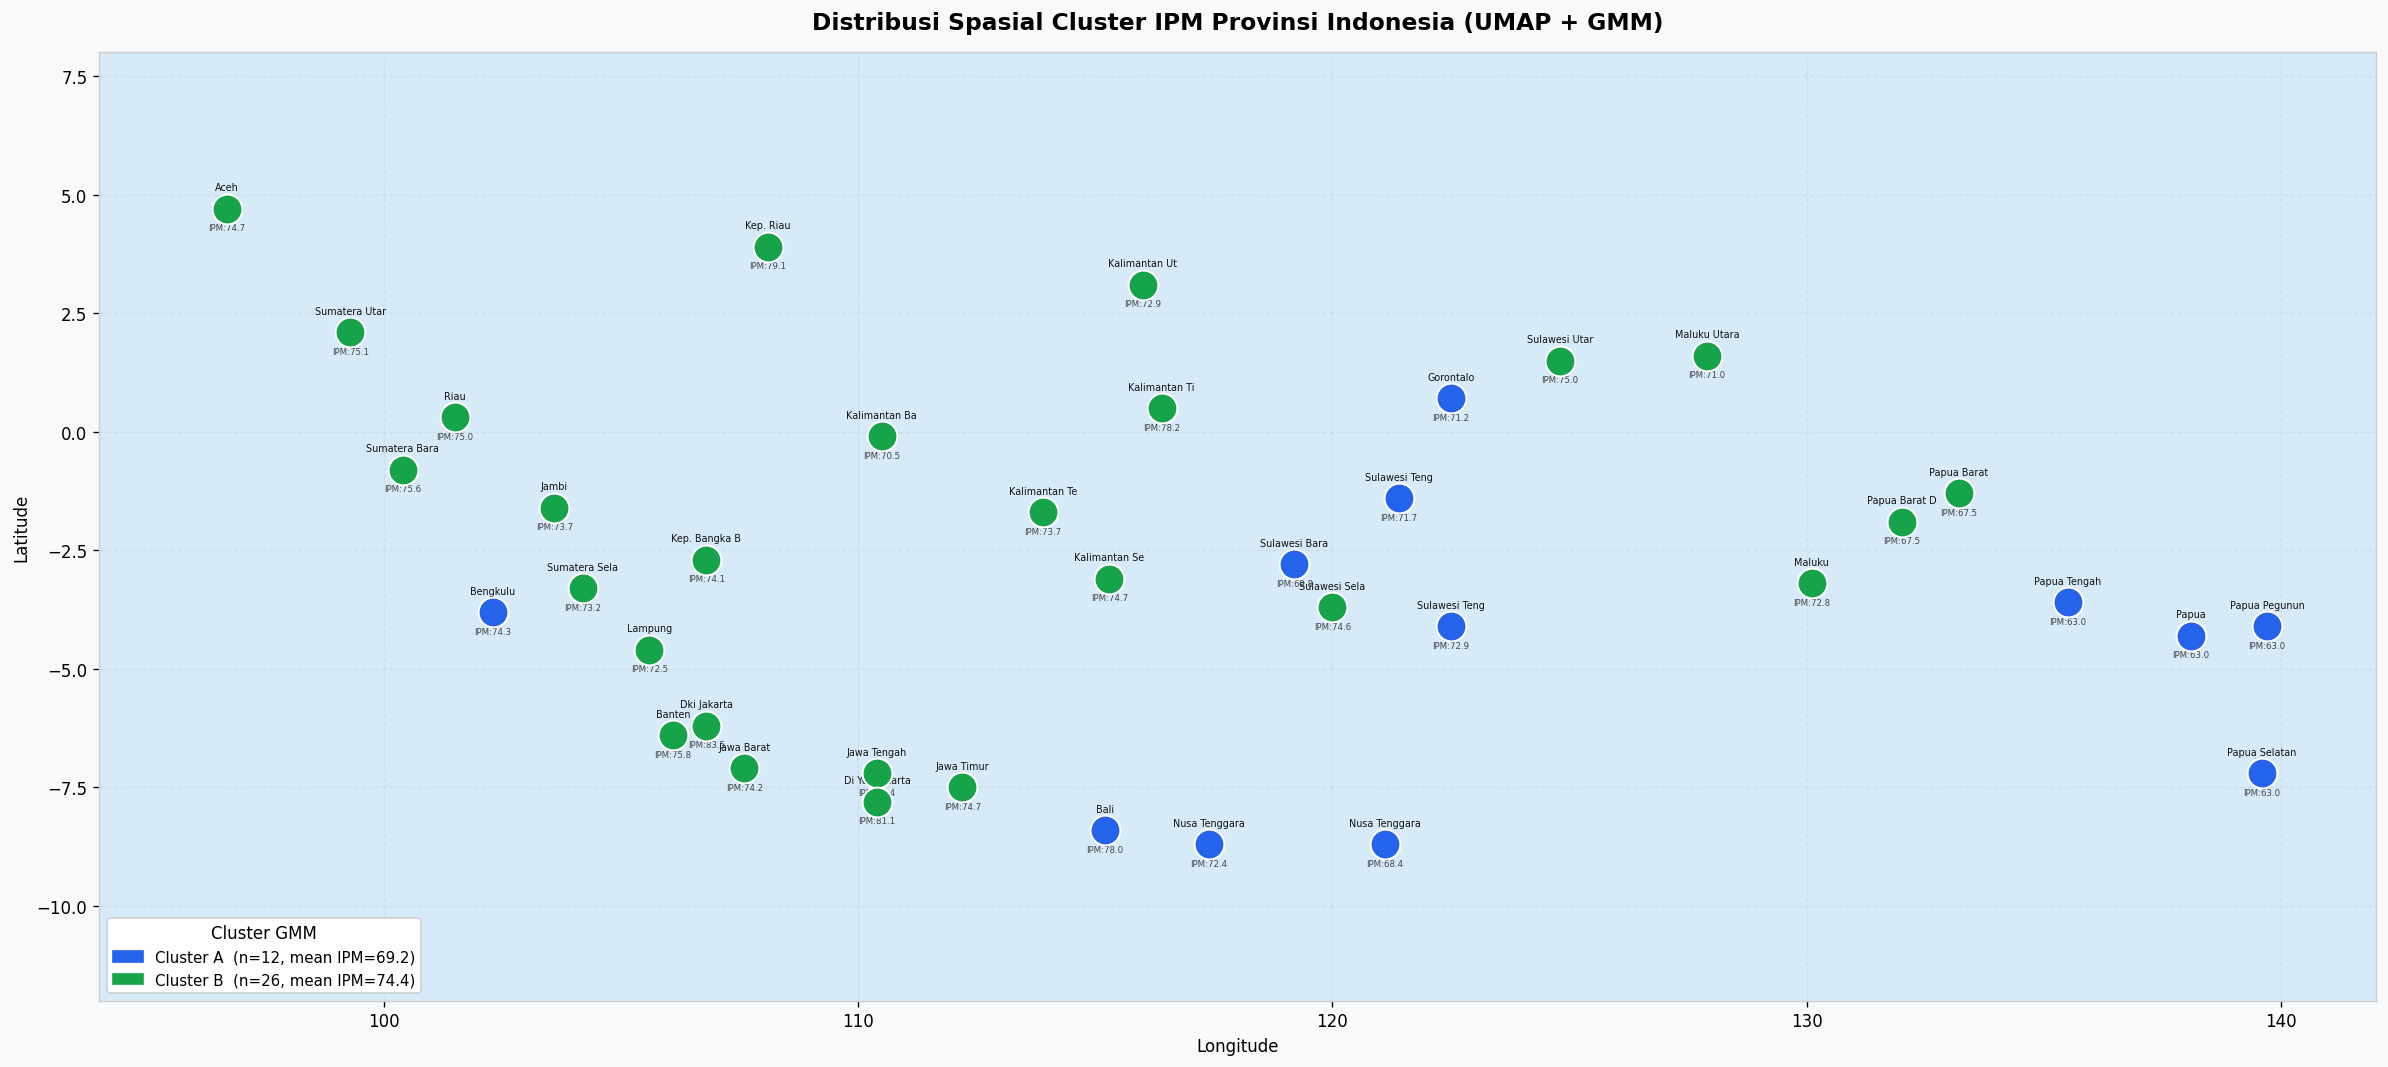

In [ ]:
PROV_COORDS = {
    'ACEH':(4.7,96.7),'SUMATERA UTARA':(2.1,99.3),'SUMATERA BARAT':(-0.8,100.4),
    'RIAU':(0.3,101.5),'JAMBI':(-1.6,103.6),'SUMATERA SELATAN':(-3.3,104.2),
    'BENGKULU':(-3.8,102.3),'LAMPUNG':(-4.6,105.6),'KEP. BANGKA BELITUNG':(-2.7,106.8),
    'KEP. RIAU':(3.9,108.1),'DKI JAKARTA':(-6.2,106.8),'JAWA BARAT':(-7.1,107.6),
    'JAWA TENGAH':(-7.2,110.4),'DI YOGYAKARTA':(-7.8,110.4),'JAWA TIMUR':(-7.5,112.2),
    'BANTEN':(-6.4,106.1),'BALI':(-8.4,115.2),'NUSA TENGGARA BARAT':(-8.7,117.4),
    'NUSA TENGGARA TIMUR':(-8.7,121.1),'KALIMANTAN BARAT':(-0.1,110.5),
    'KALIMANTAN TENGAH':(-1.7,113.9),'KALIMANTAN SELATAN':(-3.1,115.3),
    'KALIMANTAN TIMUR':(0.5,116.4),'KALIMANTAN UTARA':(3.1,116.0),
    'SULAWESI UTARA':(1.5,124.8),'SULAWESI TENGAH':(-1.4,121.4),
    'SULAWESI SELATAN':(-3.7,120.0),'SULAWESI TENGGARA':(-4.1,122.5),
    'GORONTALO':(0.7,122.5),'SULAWESI BARAT':(-2.8,119.2),
    'MALUKU':(-3.2,130.1),'MALUKU UTARA':(1.6,127.9),
    'PAPUA BARAT':(-1.3,133.2),'PAPUA BARAT DAYA':(-1.9,132.0),
    'PAPUA':(-4.3,138.1),'PAPUA SELATAN':(-7.2,139.6),
    'PAPUA TENGAH':(-3.6,135.5),'PAPUA PEGUNUNGAN':(-4.1,139.7)
}

fig, ax = plt.subplots(figsize=(20,9))
ax.set_facecolor('#D6EAF8'); fig.patch.set_facecolor('#F8F9FA')
ax.set_xlim(94,142); ax.set_ylim(-12,8)

for _, row in df_latest.iterrows():
    prov = row['provinsi']
    if prov not in PROV_COORDS: continue
    lat, lon = PROV_COORDS[prov]
    ax.scatter(lon, lat, c=PALETTE[int(row['cluster_id'])], s=320,
               zorder=5, edgecolors='white', linewidth=1.2)
    ax.annotate(prov.title()[:13], (lon,lat), fontsize=5.8, ha='center',
                xytext=(0,11), textcoords='offset points', color='#111111')
    ax.annotate(f'IPM:{row["ipm"]:.1f}', (lon,lat), fontsize=5.2, ha='center',
                xytext=(0,-13), textcoords='offset points', color='#444444')

legend_h = [
    mpatches.Patch(
        color=PALETTE[i],
        label=f"{df_latest[df_latest['cluster_id']==i]['cluster_label'].iloc[0]}  "
              f"(n={len(df_latest[df_latest['cluster_id']==i])}, "
              f"mean IPM={df_latest[df_latest['cluster_id']==i]['ipm'].mean():.1f})"
    ) for i in sorted(df_latest['cluster_id'].unique())
]
ax.legend(handles=legend_h, loc='lower left', fontsize=9, framealpha=0.92,
          title='Cluster GMM', title_fontsize=10)
ax.set_title('Distribusi Spasial Cluster IPM Provinsi Indonesia (UMAP + GMM)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.2, linestyle='--')
for sp in ax.spines.values(): sp.set_color('#CCCCCC')
plt.tight_layout()
plt.savefig('plot_choropleth_cluster.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Panel Regression: Fixed Effect Model
FEM mengendalikan heterogenitas time-invariant per provinsi. SE menggunakan cluster-robust (by entity).

In [13]:
FE_VARS  = ['aps_1315','aps_1618','aps_1924','tpt_feb','tpak_feb','pct_miskin_maret','gk_maret']
df_panel = df.copy().set_index(['provinsi','tahun'])
X_panel  = sm.add_constant(df_panel[FE_VARS].astype(float))
y_panel  = df_panel['ipm'].astype(float)

model_fe = PanelOLS(y_panel, X_panel, entity_effects=True, drop_absorbed=True)
result_fe = model_fe.fit(cov_type='clustered', cluster_entity=True)

print('=== Fixed Effect Model: IPM ~ Fitur Input Kebijakan ===')
print(result_fe.summary.tables[1].as_text())
print(f'\nR2 within   : {result_fe.rsquared:.4f}')
print(f'R2 between  : {result_fe.rsquared_between:.4f}')
print(f'R2 overall  : {result_fe.rsquared_overall:.4f}')
print(f'F-stat      : {result_fe.f_statistic.stat:.4f}  (p={result_fe.f_statistic.pval:.6f})')
print(f'N obs       : {int(result_fe.nobs)}')
sig_vars = [v for v in result_fe.params[result_fe.pvalues<0.05].index if v!='const']
print(f'Sig vars    : {sig_vars}')

=== Fixed Effect Model: IPM ~ Fitur Input Kebijakan ===
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
const                65.238     7.9023     8.2556     0.0000      49.571      80.905
aps_1315             0.0870     0.1150     0.7566     0.4510     -0.1410      0.3151
aps_1618            -0.0400     0.0688    -0.5821     0.5618     -0.1763      0.0963
aps_1924             0.0290     0.0313     0.9242     0.3575     -0.0332      0.0911
tpt_feb             -0.4494     0.1651    -2.7221     0.0076     -0.7767     -0.1221
tpak_feb             0.0163     0.0284     0.5741     0.5671     -0.0400      0.0725
pct_miskin_maret    -0.1346     0.0375    -3.5873     0.0005     -0.2090     -0.0602
gk_maret          6.278e-06  9.329e-07     6.7291     0.0000   4.428e-06   8.127e-06

R2 withi

In [14]:
coef_df = pd.DataFrame({
    'coef':result_fe.params,'std_err':result_fe.std_errors,'pvalue':result_fe.pvalues,
    'ci_low':result_fe.params - 1.96*result_fe.std_errors,
    'ci_high':result_fe.params + 1.96*result_fe.std_errors
}).drop('const', errors='ignore')
coef_df['significant']  = coef_df['pvalue'] < 0.05
coef_df['signif_star']  = coef_df['pvalue'].apply(
    lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else '')
coef_df = coef_df.sort_values('coef')

print('Tabel koefisien FEM:')
print(f'{"Variabel":<26} {"Koef":>9} {"SE":>8} {"P-val":>8} {"Sig":>5}  CI 95%')
print('-'*75)
for var, row in coef_df.iterrows():
    print(f'{VAR_LABELS.get(var,var):<26} {row["coef"]:>9.4f} {row["std_err"]:>8.4f} '
          f'{row["pvalue"]:>8.4f} {row["signif_star"]:>5}  [{row["ci_low"]:>.4f}, {row["ci_high"]:>.4f}]')

print()
print('Interpretasi variabel signifikan (within-province, ceteris paribus):')
for var, row in coef_df[coef_df['significant']].iterrows():
    arah = 'menaikkan' if row['coef']>0 else 'menurunkan'
    print(f'  {VAR_LABELS.get(var,var)}: +1 satuan {arah} IPM {abs(row["coef"]):.4f} poin '
          f'(p={row["pvalue"]:.4f}{row["signif_star"]})')

Tabel koefisien FEM:
Variabel                        Koef       SE    P-val   Sig  CI 95%
---------------------------------------------------------------------------
TPT Februari                 -0.4494   0.1651   0.0076    **  [-0.7729, -0.1258]
% Penduduk Miskin            -0.1346   0.0375   0.0005   ***  [-0.2082, -0.0611]
APS 16-18 Thn                -0.0400   0.0688   0.5618        [-0.1748, 0.0947]
Garis Kemiskinan              0.0000   0.0000   0.0000   ***  [0.0000, 0.0000]
TPAK Februari                 0.0163   0.0284   0.5671        [-0.0393, 0.0719]
APS 19-24 Thn                 0.0290   0.0313   0.3575        [-0.0325, 0.0904]
APS 13-15 Thn                 0.0870   0.1150   0.4510        [-0.1384, 0.3125]

Interpretasi variabel signifikan (within-province, ceteris paribus):
  TPT Februari: +1 satuan menurunkan IPM 0.4494 poin (p=0.0076**)
  % Penduduk Miskin: +1 satuan menurunkan IPM 0.1346 poin (p=0.0005***)
  Garis Kemiskinan: +1 satuan menaikkan IPM 0.0000 poin (p=0.0000

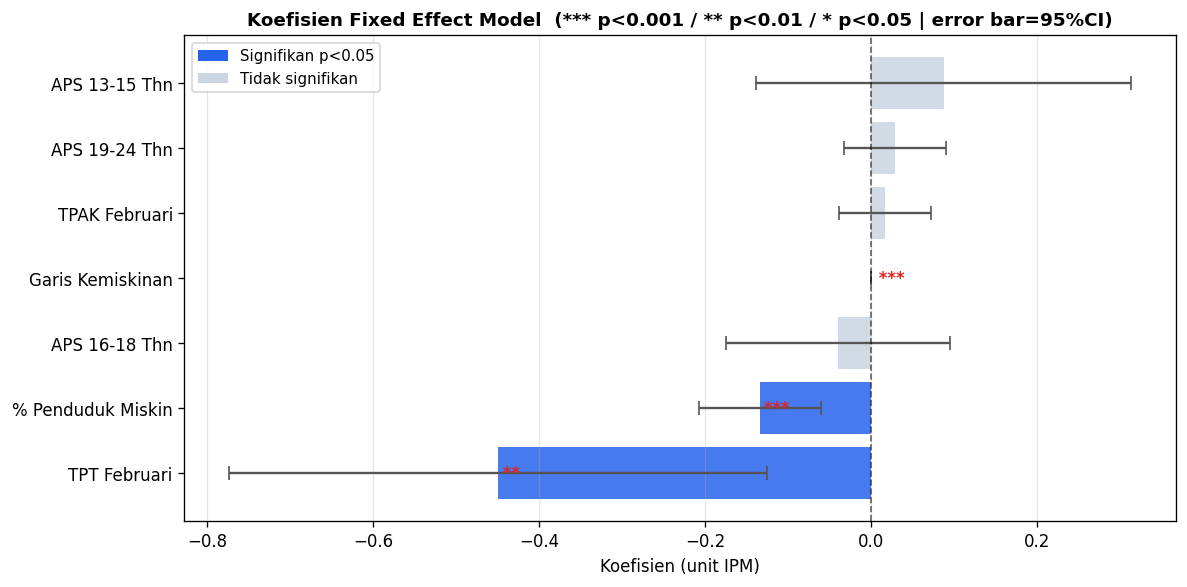

In [15]:
fig, ax = plt.subplots(figsize=(10,5))
bar_colors = ['#2563EB' if s else '#CBD5E1' for s in coef_df['significant']]
bar_labels  = [VAR_LABELS.get(v,v) for v in coef_df.index]
bars = ax.barh(bar_labels, coef_df['coef'], xerr=1.96*coef_df['std_err'],
               color=bar_colors, alpha=0.85, capsize=4,
               error_kw={'linewidth':1.4,'ecolor':'#555'})
ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
for bar, val, star in zip(bars, coef_df['coef'], coef_df['signif_star']):
    if star:
        ax.text(val+(0.002 if val>=0 else -0.002), bar.get_y()+bar.get_height()/2,
                f' {star}', va='center', fontsize=10, color='#DC2626', fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#2563EB',label='Signifikan p<0.05'),
                   Patch(facecolor='#CBD5E1',label='Tidak signifikan')], fontsize=9)
ax.set_title('Koefisien Fixed Effect Model  (*** p<0.001 / ** p<0.01 / * p<0.05 | error bar=95%CI)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Koefisien (unit IPM)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_fe_coef.png', bbox_inches='tight')
plt.show()

## 6. XGBoost + SHAP
Data diurutkan berdasarkan waktu sebelum TimeSeriesSplit. `tahun` tidak dimasukkan sebagai fitur — bukan variabel kebijakan yang dapat diintervensi.

In [16]:
df_sorted = df.sort_values(['tahun','provinsi']).reset_index(drop=True)
X_ml = df_sorted[FEATURES].astype(float)
y_ml = df_sorted['ipm'].astype(float)

# Verifikasi dtype sebelum XGBoost
assert all(X_ml.dtypes.apply(lambda d: np.issubdtype(d, np.number))), 'Non-numeric di X_ml!'

xgb_params = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, reg_alpha=0.5, reg_lambda=1.5,
    min_child_weight=3, random_state=42, verbosity=0)

tscv = TimeSeriesSplit(n_splits=3)
cv_r2, cv_mae, cv_rmse = [], [], []

print('TimeSeriesSplit Cross-Validation XGBoost (3-fold):')
print(f'{"Fold":>5} | {"Train":>7} | {"Test":>7} | {"Test Tahun":>12} | {"R2":>8} | {"MAE":>8} | {"RMSE":>8}')
print('-'*70)

for fold, (tr, te) in enumerate(tscv.split(X_ml), 1):
    m = XGBRegressor(**xgb_params)
    m.fit(X_ml.iloc[tr], y_ml.iloc[tr])
    pred = m.predict(X_ml.iloc[te])
    r2   = r2_score(y_ml.iloc[te], pred)
    mae  = mean_absolute_error(y_ml.iloc[te], pred)
    rmse = np.sqrt(mean_squared_error(y_ml.iloc[te], pred))
    cv_r2.append(r2); cv_mae.append(mae); cv_rmse.append(rmse)
    yr = f"{df_sorted['tahun'].iloc[te].min()}-{df_sorted['tahun'].iloc[te].max()}"
    print(f'{fold:>5} | {len(tr):>7} | {len(te):>7} | {yr:>12} | {r2:>8.4f} | {mae:>8.4f} | {rmse:>8.4f}')

print('-'*70)
print(f'{"Rata2":>5}   {"":>7}   {"":>7}   {"":>12}   {np.mean(cv_r2):>8.4f}   {np.mean(cv_mae):>8.4f}   {np.mean(cv_rmse):>8.4f}')
print(f'{"Std":>5}   {"":>7}   {"":>7}   {"":>12}   {np.std(cv_r2):>8.4f}   {np.std(cv_mae):>8.4f}   {np.std(cv_rmse):>8.4f}')

xgb_model = XGBRegressor(**xgb_params)
xgb_model.fit(X_ml, y_ml)
y_pred_train = xgb_model.predict(X_ml)
print(f'\nModel final (full data) — R2={r2_score(y_ml,y_pred_train):.4f}, '
      f'MAE={mean_absolute_error(y_ml,y_pred_train):.4f}, '
      f'RMSE={np.sqrt(mean_squared_error(y_ml,y_pred_train)):.4f}')

TimeSeriesSplit Cross-Validation XGBoost (3-fold):
 Fold |   Train |    Test |   Test Tahun |       R2 |      MAE |     RMSE
----------------------------------------------------------------------
    1 |      40 |      37 |    2022-2023 |   0.8949 |   1.1171 |   1.5433
    2 |      77 |      37 |    2023-2024 |   0.9389 |   0.9275 |   1.1402
    3 |     114 |      37 |    2024-2024 |   0.9448 |   0.5610 |   1.1003
----------------------------------------------------------------------
Rata2                                        0.9262     0.8685     1.2613
  Std                                        0.0223     0.2308     0.2001

Model final (full data) — R2=0.9991, MAE=0.0982, RMSE=0.1405


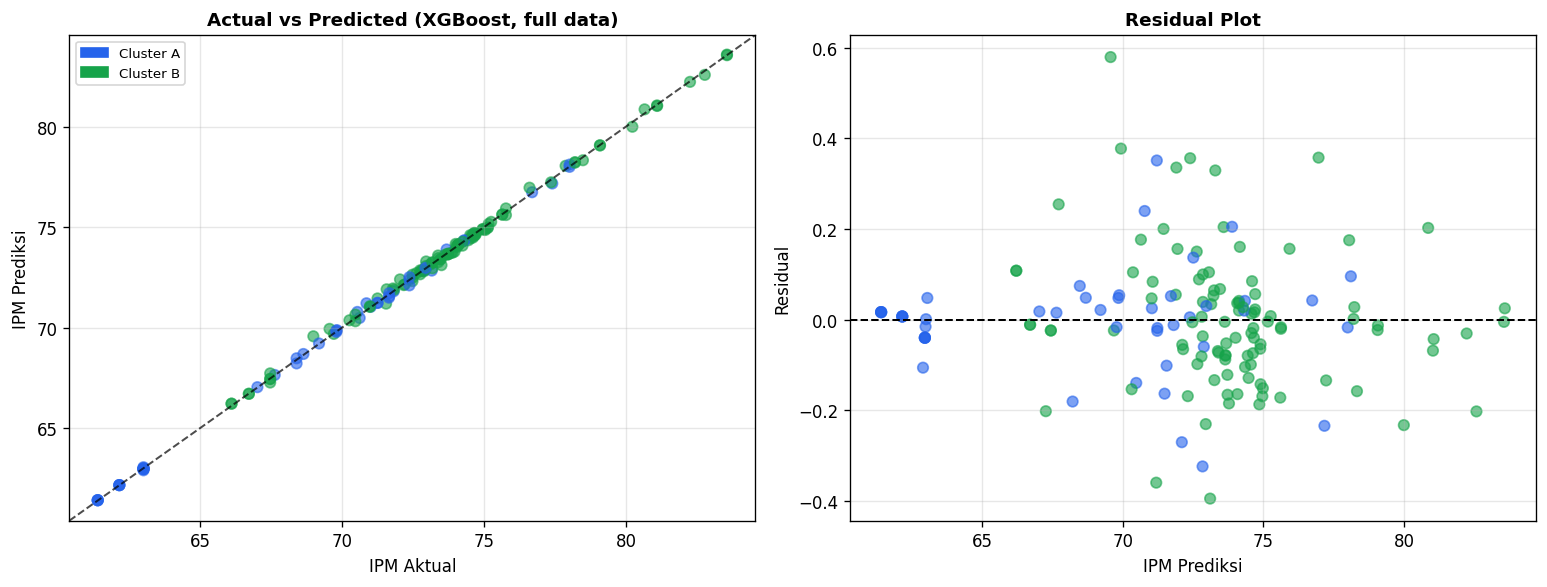

In [17]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
cl_colors = [PALETTE[int(df_sorted['cluster_id'].iloc[i])] for i in range(len(df_sorted))]

axes[0].scatter(y_ml, y_pred_train, c=cl_colors, alpha=0.6, s=40)
lim = [y_ml.min()-1, y_ml.max()+1]
axes[0].plot(lim, lim, 'k--', linewidth=1.2, alpha=0.7)
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('IPM Aktual'); axes[0].set_ylabel('IPM Prediksi')
axes[0].set_title('Actual vs Predicted (XGBoost, full data)', fontsize=11, fontweight='bold')
axes[0].grid(alpha=0.3)
legend_h2 = [mpatches.Patch(color=PALETTE[i],
              label=df_latest[df_latest['cluster_id']==i]['cluster_label'].iloc[0])
              for i in range(optimal_k)]
axes[0].legend(handles=legend_h2, fontsize=8)

residuals = y_pred_train - y_ml
axes[1].scatter(y_pred_train, residuals, c=cl_colors, alpha=0.6, s=40)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('IPM Prediksi'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot', fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plot_xgb_fit.png', bbox_inches='tight')
plt.show()

In [18]:
explainer    = shap.TreeExplainer(xgb_model)
shap_values  = explainer.shap_values(X_ml)
assert shap_values.shape == X_ml.shape

shap_df       = pd.DataFrame(shap_values, columns=FEATURES)
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

total_shap = mean_abs_shap.sum()
print('SHAP Feature Importance (Mean |SHAP|):')
print(f'{"Rank":<5} {"Variabel":<28} {"Mean|SHAP|":>11} {"Kontribusi %":>13} {"Tier"}')
print('-'*65)
for rank, (feat, val) in enumerate(mean_abs_shap.items(), 1):
    tier = 'Dominan  ' if rank==1 else 'Penting  ' if rank<=3 else 'Pendukung'
    print(f'{rank:<5} {FEATURE_LABELS[feat]:<28} {val:>11.4f} {val/total_shap*100:>12.1f}%  {tier}')

SHAP Feature Importance (Mean |SHAP|):
Rank  Variabel                      Mean|SHAP|  Kontribusi % Tier
-----------------------------------------------------------------
1     % Penduduk Miskin                 1.6191         36.7%  Dominan  
2     APS 13-15 Thn                     1.2836         29.1%  Penting  
3     APS 16-18 Thn                     0.4118          9.3%  Penting  
4     Garis Kemiskinan                  0.2951          6.7%  Pendukung
5     TPT Februari                      0.2866          6.5%  Pendukung
6     TPAK Februari                     0.2734          6.2%  Pendukung
7     APS 19-24 Thn                     0.2421          5.5%  Pendukung


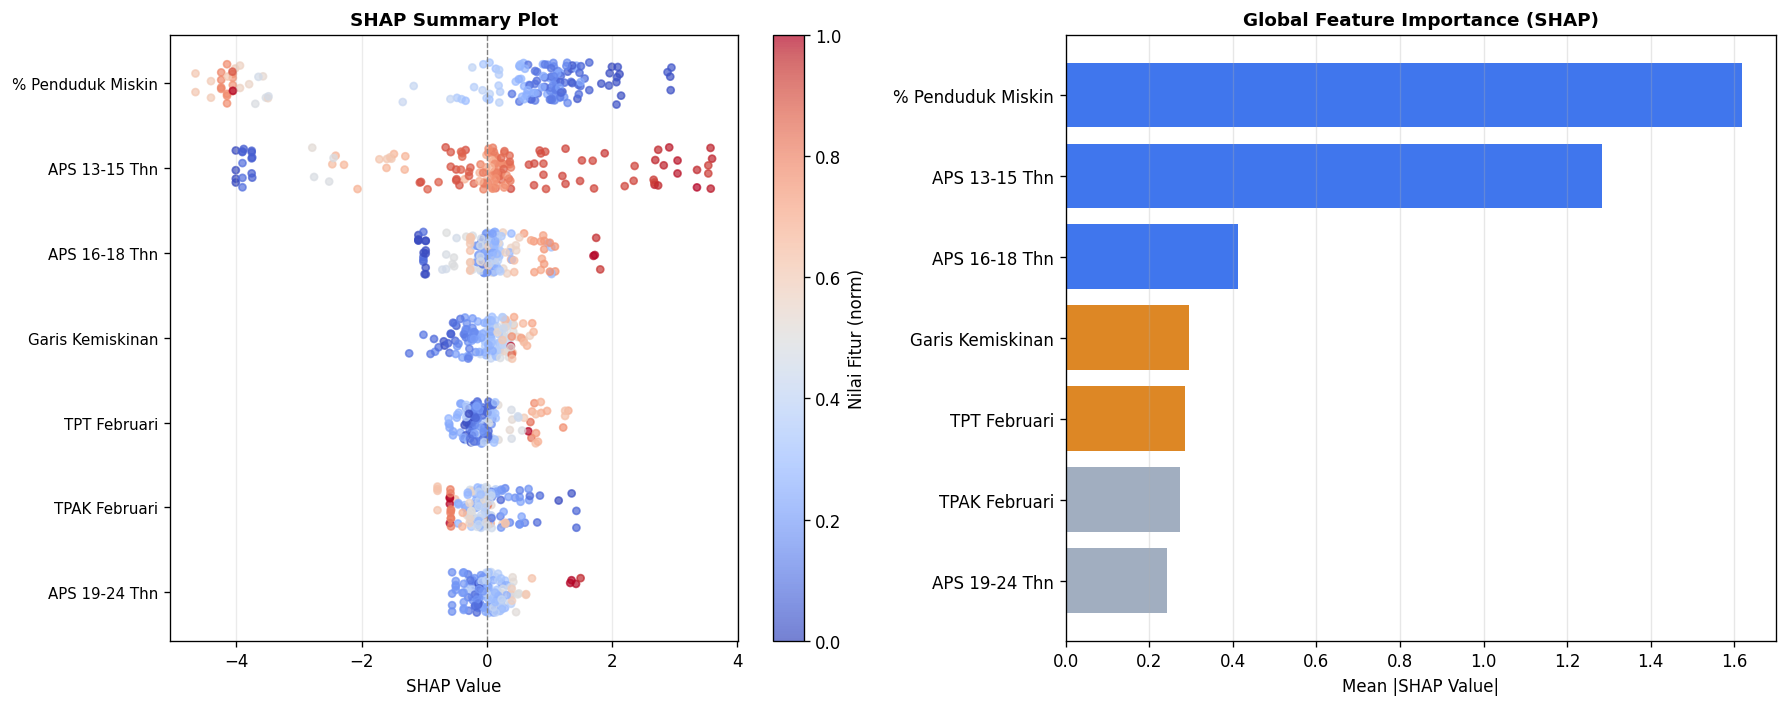

In [19]:
fig, axes = plt.subplots(1,2,figsize=(15,6))
feat_order   = mean_abs_shap.index.tolist()
feat_labels_ = [FEATURE_LABELS[f] for f in feat_order]
rng = np.random.default_rng(42)

for rank, feat in enumerate(feat_order[::-1]):
    sv   = shap_df[feat].values
    fv   = X_ml[feat].values
    fv_n = (fv - fv.min()) / (fv.ptp()+1e-9)
    jit  = rng.uniform(-0.25, 0.25, len(sv))
    sc   = axes[0].scatter(sv, np.full(len(sv),rank)+jit, c=fv_n,
                            cmap='coolwarm', vmin=0, vmax=1, s=18, alpha=0.7)

plt.colorbar(sc, ax=axes[0], label='Nilai Fitur (norm)')
axes[0].set_yticks(range(len(feat_order)))
axes[0].set_yticklabels(feat_labels_[::-1], fontsize=9)
axes[0].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('SHAP Value')
axes[0].set_title('SHAP Summary Plot', fontsize=11, fontweight='bold')
axes[0].grid(axis='x', alpha=0.25)

bar_colors_ = [PALETTE[0] if i<3 else PALETTE[3] if i<5 else '#94A3B8'
               for i in range(len(mean_abs_shap))]
axes[1].barh(feat_labels_[::-1], mean_abs_shap.values[::-1],
              color=bar_colors_[::-1], alpha=0.88)
axes[1].set_xlabel('Mean |SHAP Value|')
axes[1].set_title('Global Feature Importance (SHAP)', fontsize=11, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_shap.png', bbox_inches='tight')
plt.show()

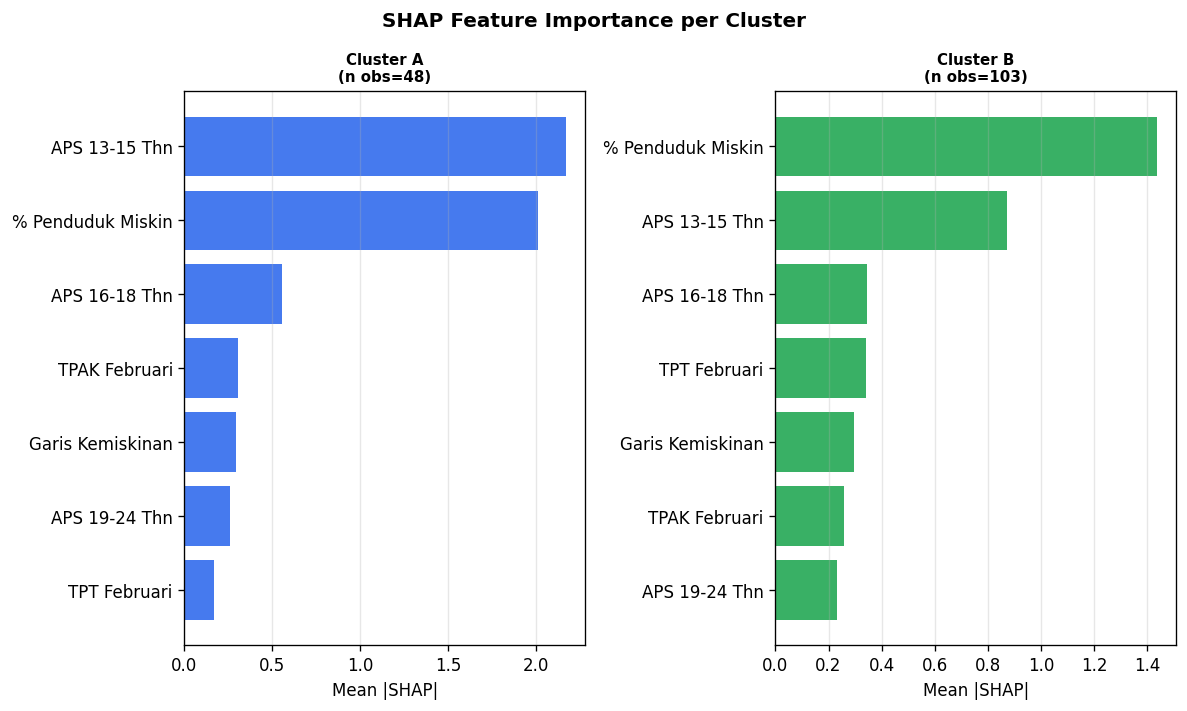

In [20]:
fig, axes = plt.subplots(1, optimal_k, figsize=(5*optimal_k, 6))
if optimal_k == 1: axes = [axes]

for i, cl_id in enumerate(sorted(df_latest['cluster_id'].unique())):
    cl_lbl     = df_latest[df_latest['cluster_id']==cl_id]['cluster_label'].iloc[0]
    prov_in_cl = df_latest[df_latest['cluster_id']==cl_id]['provinsi'].tolist()
    mask_cl    = df_sorted['provinsi'].isin(prov_in_cl)
    shap_cl    = pd.DataFrame(shap_values[mask_cl.values], columns=FEATURES).abs().mean().sort_values(ascending=True)

    axes[i].barh([FEATURE_LABELS[f] for f in shap_cl.index], shap_cl.values,
                  color=PALETTE[i], alpha=0.85)
    axes[i].set_title(f'{cl_lbl}\n(n obs={mask_cl.sum()})', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Mean |SHAP|')
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('SHAP Feature Importance per Cluster', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_shap_per_cluster.png', bbox_inches='tight')
plt.show()

## 7. Forecasting IPM 2025–2027
Strategi: OLS linear trend per fitur per provinsi, slope di-damp 30%/langkah, prediksi via XGBoost global. Nilai di-clip ke [50, 95].

In [21]:
df_last = df[df['tahun']==2024].copy()
forecast_rows = []

for _, row in df_last.iterrows():
    prov      = row['provinsi']
    prov_hist = df[df['provinsi']==prov].sort_values('tahun')
    years     = prov_hist['tahun'].values.astype(float)

    for fy in [2025, 2026, 2027]:
        steps    = int(fy - years[-1])
        feat_row = {}
        for feat in FEATURES:
            vals = prov_hist[feat].values.astype(float)
            if len(vals) >= 2 and not np.isnan(vals).any():
                coeffs       = np.polyfit(years - years[0], vals, 1)
                damped_slope = coeffs[0] * (0.7 ** steps)
                feat_row[feat] = float(vals[-1] + damped_slope * steps)
            else:
                feat_row[feat] = float(vals[-1])

        X_pred   = pd.DataFrame([feat_row], columns=FEATURES).astype(float)
        ipm_pred = float(np.clip(xgb_model.predict(X_pred)[0], 50, 95))
        cl_id    = int(cluster_map.get(prov, 0))
        cl_lbl   = df_latest[df_latest['provinsi']==prov]['cluster_label'].values[0]
        forecast_rows.append({'provinsi':prov,'tahun':fy,'ipm_forecast':round(ipm_pred,3),
                               'cluster_id':cl_id,'cluster_label':cl_lbl})

df_forecast = pd.DataFrame(forecast_rows)
df_hist_long = df[['provinsi','tahun','ipm']].copy()
df_hist_long['cluster_id']    = df_hist_long['provinsi'].map(cluster_map)
df_hist_long['cluster_label'] = df_hist_long['provinsi'].map(clusterlbl_map)
df_hist_long = df_hist_long.rename(columns={'ipm':'ipm_forecast'})
df_forecast_full = pd.concat([df_hist_long, df_forecast], ignore_index=True)

ipm24_map = df_latest.set_index('provinsi')['ipm']
print('Preview Forecast 2025–2027:')
print(f'{"Provinsi":<30} {"IPM 2024":>9} {"2025":>7} {"2026":>7} {"2027":>7} {"Delta":>7}')
print('-'*72)
for prov in sorted(df_forecast['provinsi'].unique()):
    v = df_forecast[df_forecast['provinsi']==prov].set_index('tahun')['ipm_forecast']
    i24 = ipm24_map.get(prov, float('nan'))
    d27 = v.get(2027, float('nan')) - i24
    print(f'{prov:<30} {i24:>9.2f} {v.get(2025,float("nan")):>7.3f} '
          f'{v.get(2026,float("nan")):>7.3f} {v.get(2027,float("nan")):>7.3f} {d27:>+7.3f}')

Preview Forecast 2025–2027:
Provinsi                        IPM 2024    2025    2026    2027   Delta
------------------------------------------------------------------------
ACEH                               74.70  73.245  73.253  73.253  -1.447
BALI                               78.01  77.476  77.574  77.574  -0.436
BANTEN                             75.77  75.244  75.545  75.466  -0.304
BENGKULU                           74.30  74.412  74.392  74.392  +0.092
DI YOGYAKARTA                      81.09  80.903  80.205  80.205  -0.885
DKI JAKARTA                        83.55  81.001  80.620  80.614  -2.936
GORONTALO                          71.25  70.528  70.529  70.529  -0.721
JAMBI                              73.73  73.629  73.622  73.615  -0.115
JAWA BARAT                         74.24  74.095  73.933  73.933  -0.307
JAWA TENGAH                        73.39  73.056  73.120  73.120  -0.270
JAWA TIMUR                         74.65  73.671  73.645  73.650  -1.000
KALIMANTAN BARAT       

In [22]:
fc_2027 = df_forecast[df_forecast['tahun']==2027].copy()

print('Statistik forecast IPM 2027 per cluster:')
print(fc_2027.groupby('cluster_label')['ipm_forecast']
      .agg(['mean','min','max','std']).round(3).to_string())

print()
top5 = fc_2027.nlargest(5,'ipm_forecast')[['provinsi','ipm_forecast','cluster_label']].copy()
top5['ipm_2024'] = top5['provinsi'].map(ipm24_map)
top5['delta']    = (top5['ipm_forecast'] - top5['ipm_2024']).round(3)
print('5 Provinsi IPM Tertinggi 2027:')
print(top5.to_string(index=False))

print()
bot5 = fc_2027.nsmallest(5,'ipm_forecast')[['provinsi','ipm_forecast','cluster_label']].copy()
bot5['ipm_2024'] = bot5['provinsi'].map(ipm24_map)
bot5['delta']    = (bot5['ipm_forecast'] - bot5['ipm_2024']).round(3)
print('5 Provinsi IPM Terendah 2027:')
print(bot5.to_string(index=False))

Statistik forecast IPM 2027 per cluster:
                 mean     min     max    std
cluster_label                               
Cluster A      70.160  64.105  77.574  4.124
Cluster B      74.224  68.851  80.614  2.677

5 Provinsi IPM Tertinggi 2027:
        provinsi  ipm_forecast cluster_label  ipm_2024  delta
     DKI JAKARTA        80.614     Cluster B     83.55 -2.936
   DI YOGYAKARTA        80.205     Cluster B     81.09 -0.885
       KEP. RIAU        78.840     Cluster B     79.08 -0.240
KALIMANTAN TIMUR        78.193     Cluster B     78.20 -0.007
            BALI        77.574     Cluster A     78.01 -0.436

5 Provinsi IPM Terendah 2027:
           provinsi  ipm_forecast cluster_label  ipm_2024  delta
   PAPUA PEGUNUNGAN        64.105     Cluster A     63.01  1.095
       PAPUA TENGAH        64.121     Cluster A     63.01  1.111
      PAPUA SELATAN        67.375     Cluster A     63.01  4.365
              PAPUA        68.152     Cluster A     63.01  5.142
NUSA TENGGARA TIMUR

In [24]:
ipm_2024_s = df_latest.set_index('provinsi')['ipm']
ipm_2027_s = fc_2027.set_index('provinsi')['ipm_forecast']
growth_df  = pd.DataFrame({'ipm_2024':ipm_2024_s,'ipm_2027':ipm_2027_s,
    'cluster_id':df_latest.set_index('provinsi')['cluster_id'],
    'cluster_label':df_latest.set_index('provinsi')['cluster_label']}).dropna()
growth_df['delta'] = (growth_df['ipm_2027'] - growth_df['ipm_2024']).round(4)

mean_ipm_2024 = growth_df['ipm_2024'].mean()
mean_delta    = growth_df['delta'].mean()
paradox  = growth_df[(growth_df['ipm_2024']>mean_ipm_2024)&(growth_df['delta']<mean_delta)].sort_values('delta')
underdog = growth_df[(growth_df['ipm_2024']<mean_ipm_2024)&(growth_df['delta']>mean_delta)].sort_values('delta',ascending=False)

print(f'Rata-rata IPM 2024        : {mean_ipm_2024:.2f}')
print(f'Rata-rata delta 2024->2027: {mean_delta:.4f}')
print(f'Range delta               : {growth_df["delta"].min():.3f} s.d. {growth_df["delta"].max():.3f}')
print()
print('Provinsi PARADOKS (IPM > rata-rata, delta < rata-rata):')
print(paradox[['ipm_2024','ipm_2027','delta','cluster_label']].to_string())
print()
print('Provinsi UNDERDOG (IPM < rata-rata, delta > rata-rata):')
print(underdog[['ipm_2024','ipm_2027','delta','cluster_label']].to_string())

Rata-rata IPM 2024        : 72.76
Rata-rata delta 2024->2027: 0.1855
Range delta               : -3.025 s.d. 5.142

Provinsi PARADOKS (IPM > rata-rata, delta < rata-rata):
                      ipm_2024  ipm_2027  delta cluster_label
provinsi                                                     
SULAWESI SELATAN         74.60    71.575 -3.025     Cluster B
DKI JAKARTA              83.55    80.614 -2.936     Cluster B
ACEH                     74.70    73.253 -1.447     Cluster B
SUMATERA UTARA           75.13    74.091 -1.039     Cluster B
KALIMANTAN TENGAH        73.73    72.705 -1.025     Cluster B
JAWA TIMUR               74.65    73.650 -1.000     Cluster B
DI YOGYAKARTA            81.09    80.205 -0.885     Cluster B
SULAWESI UTARA           75.04    74.186 -0.854     Cluster B
SULAWESI TENGGARA        72.94    72.290 -0.650     Cluster A
RIAU                     74.95    74.451 -0.499     Cluster B
SUMATERA BARAT           75.64    75.181 -0.459     Cluster B
BALI                  

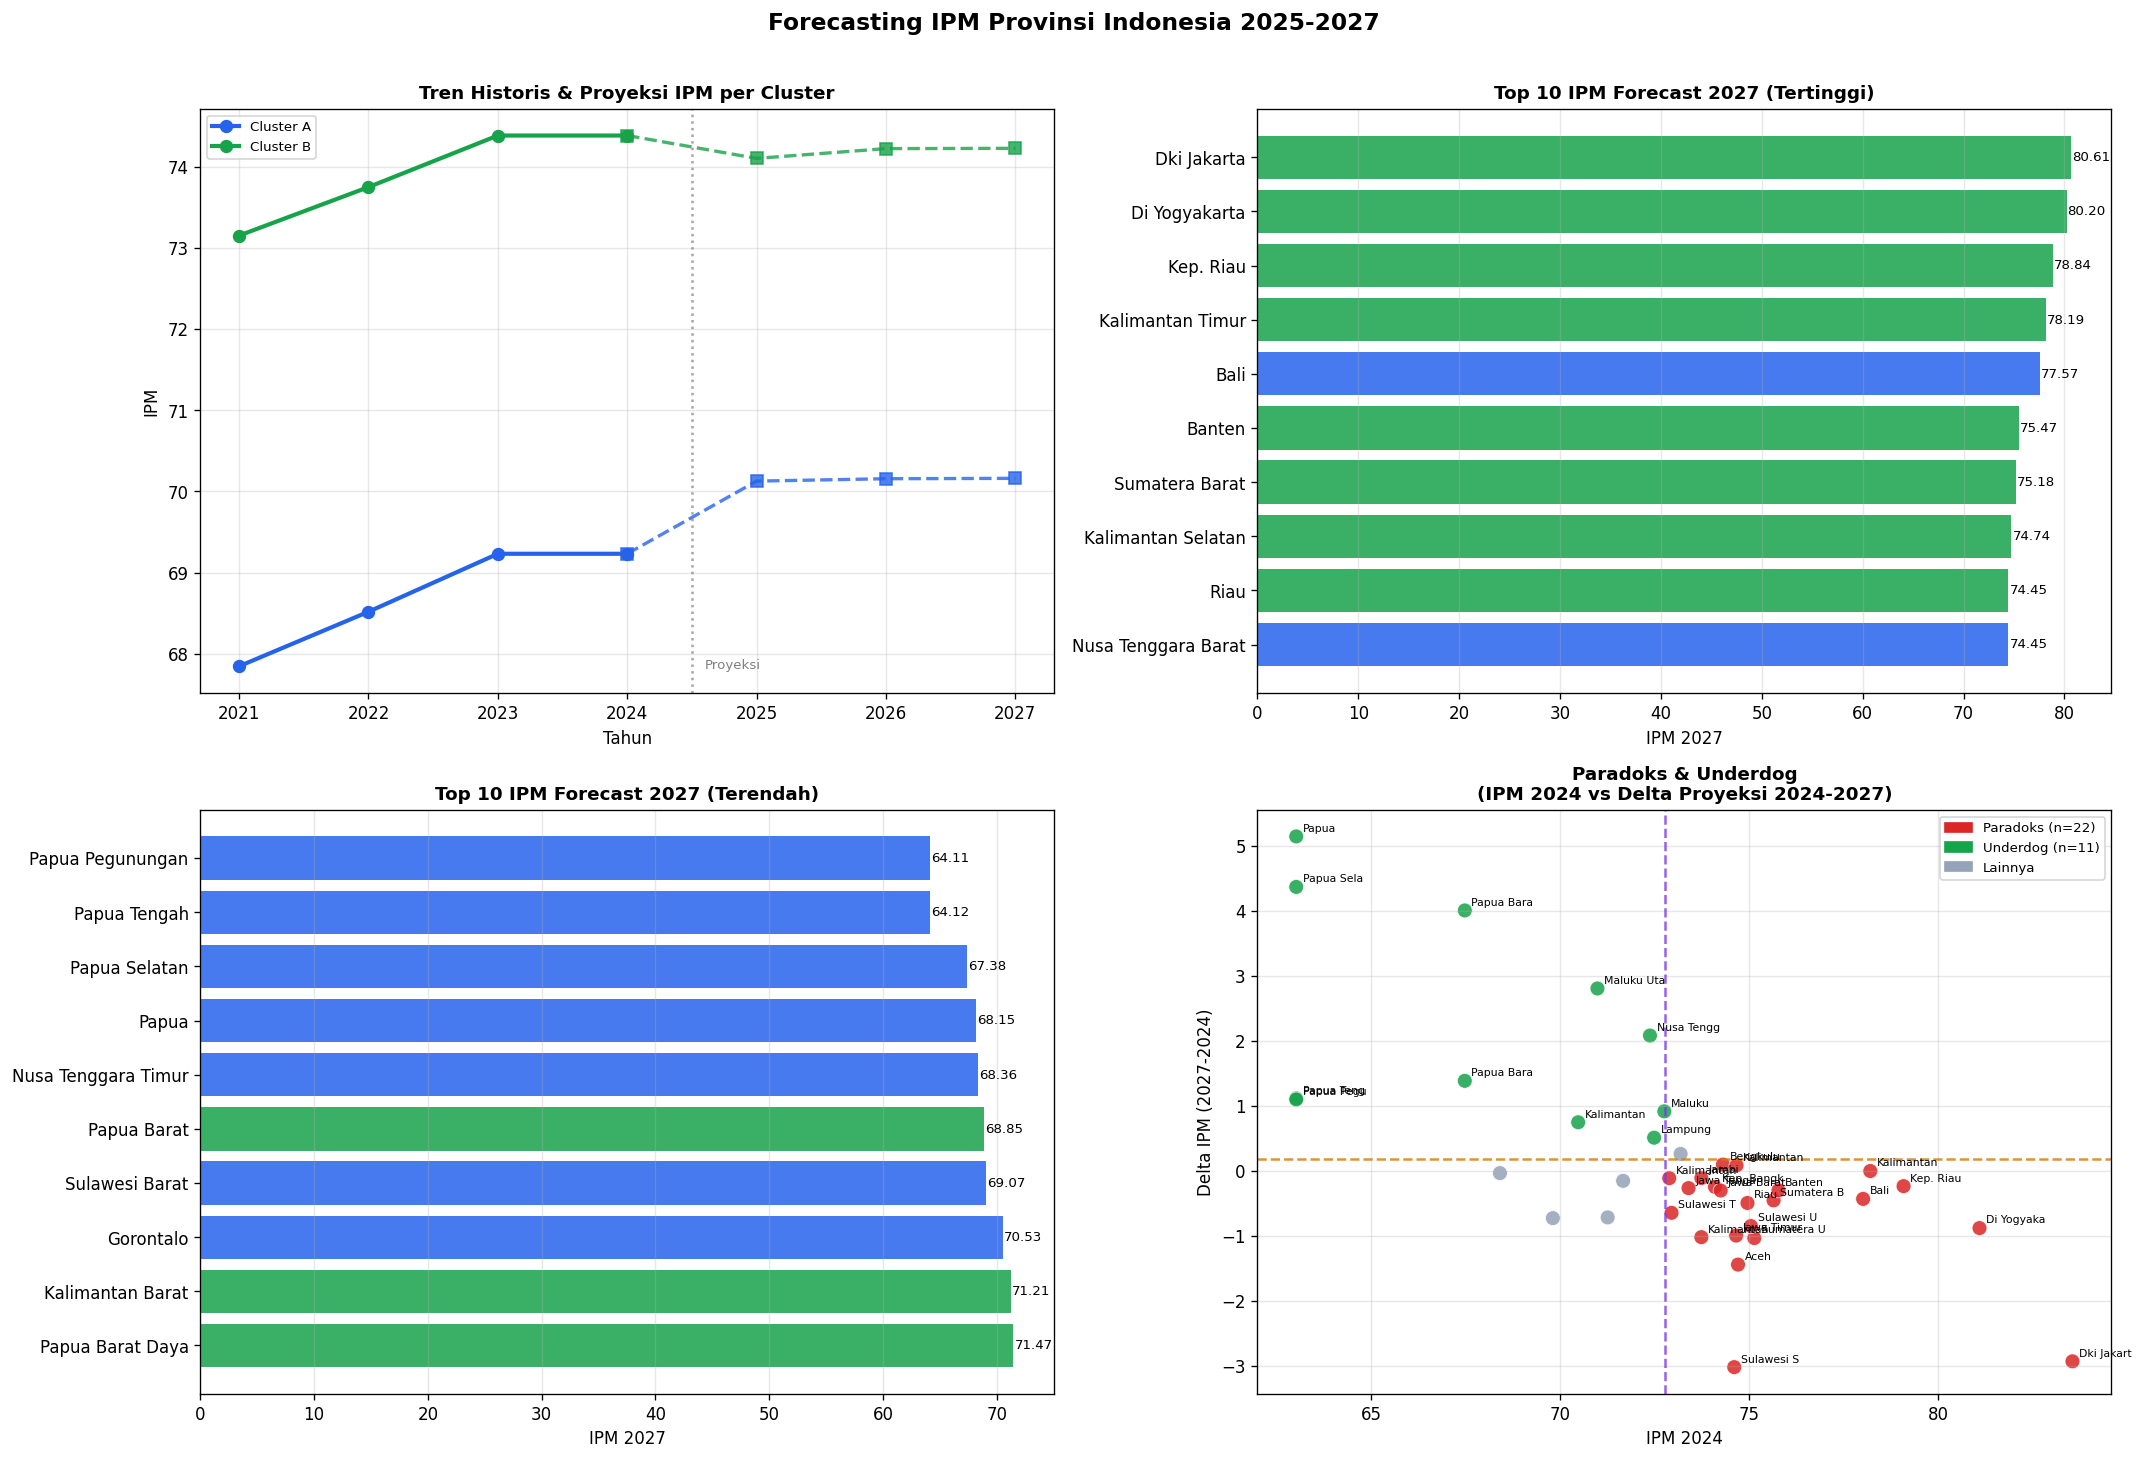

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(18,12))

ax1 = axes[0,0]
for cl_id in sorted(df_forecast_full['cluster_id'].dropna().unique()):
    cl_id  = int(cl_id)
    cl_lbl = df_latest[df_latest['cluster_id']==cl_id]['cluster_label'].iloc[0]
    cl_d   = df_forecast_full[df_forecast_full['cluster_id']==cl_id].groupby('tahun')['ipm_forecast'].mean()
    hm = cl_d.index <= 2024; fm = cl_d.index >= 2024
    ax1.plot(cl_d.index[hm], cl_d.values[hm], 'o-', color=PALETTE[cl_id],
             label=cl_lbl, linewidth=2.5, markersize=7)
    ax1.plot(cl_d.index[fm], cl_d.values[fm], 's--', color=PALETTE[cl_id],
             linewidth=2, markersize=7, alpha=0.8)
ax1.axvline(2024.5, color='gray', linestyle=':', alpha=0.7)
ax1.text(2024.6, ax1.get_ylim()[0]+0.3, 'Proyeksi', fontsize=8, color='gray')
ax1.set_title('Tren Historis & Proyeksi IPM per Cluster', fontsize=11, fontweight='bold')
ax1.set_xlabel('Tahun'); ax1.set_ylabel('IPM')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2 = axes[0,1]
top10 = fc_2027.nlargest(10,'ipm_forecast').sort_values('ipm_forecast')
ax2.barh(top10['provinsi'].str.title(), top10['ipm_forecast'],
          color=[PALETTE[int(c)] for c in top10['cluster_id']], alpha=0.85)
ax2.set_title('Top 10 IPM Forecast 2027 (Tertinggi)', fontsize=11, fontweight='bold')
ax2.set_xlabel('IPM 2027')
ax2.grid(axis='x', alpha=0.3)
for i, (_,row) in enumerate(top10.iterrows()):
    ax2.text(row['ipm_forecast']+0.1, i, f'{row["ipm_forecast"]:.2f}', va='center', fontsize=8)

ax3 = axes[1,0]
bot10 = fc_2027.nsmallest(10,'ipm_forecast').sort_values('ipm_forecast',ascending=False)
ax3.barh(bot10['provinsi'].str.title(), bot10['ipm_forecast'],
          color=[PALETTE[int(c)] for c in bot10['cluster_id']], alpha=0.85)
ax3.set_title('Top 10 IPM Forecast 2027 (Terendah)', fontsize=11, fontweight='bold')
ax3.set_xlabel('IPM 2027')
ax3.grid(axis='x', alpha=0.3)
for i, (_,row) in enumerate(bot10.iterrows()):
    ax3.text(row['ipm_forecast']+0.1, i, f'{row["ipm_forecast"]:.2f}', va='center', fontsize=8)

ax4 = axes[1,1]
def cat_color(prov):
    if prov in paradox.index: return '#DC2626'
    if prov in underdog.index: return '#16A34A'
    return '#94A3B8'
ax4.scatter(growth_df['ipm_2024'], growth_df['delta'],
             c=[cat_color(p) for p in growth_df.index], s=80, alpha=0.85,
             edgecolors='white', linewidth=0.5)
ax4.axhline(mean_delta, color='#D97706', linestyle='--', alpha=0.8, label=f'Rata-rata delta ({mean_delta:.3f})')
ax4.axvline(mean_ipm_2024, color='#7C3AED', linestyle='--', alpha=0.8, label=f'Rata-rata IPM ({mean_ipm_2024:.2f})')
for prov, row in growth_df.iterrows():
    if prov in paradox.index or prov in underdog.index:
        ax4.annotate(prov.title()[:10], (row['ipm_2024'],row['delta']),
                     fontsize=6.5, xytext=(4,3), textcoords='offset points')
ax4.legend(handles=[
    mpatches.Patch(color='#DC2626',label=f'Paradoks (n={len(paradox)})'),
    mpatches.Patch(color='#16A34A',label=f'Underdog (n={len(underdog)})'),
    mpatches.Patch(color='#94A3B8',label='Lainnya'),
], fontsize=8)
ax4.set_title('Paradoks & Underdog\n(IPM 2024 vs Delta Proyeksi 2024-2027)',
               fontsize=11, fontweight='bold')
ax4.set_xlabel('IPM 2024'); ax4.set_ylabel('Delta IPM (2027-2024)')
ax4.grid(alpha=0.3)

plt.suptitle('Forecasting IPM Provinsi Indonesia 2025-2027',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_forecasting.png', bbox_inches='tight')
plt.show()

## 8. Insight Gabungan

In [27]:
print('='*72)
print('INSIGHT KOMPREHENSIF: ANALISIS IPM PROVINSI INDONESIA')
print('='*72)

print(f'\n[1] CLUSTERING (UMAP + GMM, K={optimal_k})')
print(f'    Sil={sil_final:.4f}  DB={db_final:.4f}  CH={ch_final:.4f}')
for cl_id in sorted(df_latest['cluster_id'].unique()):
    sub    = df_latest[df_latest['cluster_id']==cl_id]
    cl_lbl = sub['cluster_label'].iloc[0]
    print(f'\n  {cl_lbl}  (n={len(sub)}, mean conf={sub["cluster_confidence"].mean():.4f})')
    print(f'  IPM       : mean={sub["ipm"].mean():.2f}, min={sub["ipm"].min():.2f}, max={sub["ipm"].max():.2f}')
    print(f'  % Miskin  : {sub["pct_miskin_maret"].mean():.2f}%')
    print(f'  TPT Feb   : {sub["tpt_feb"].mean():.2f}%')
    print(f'  TPAK Feb  : {sub["tpak_feb"].mean():.2f}%')
    print(f'  Anggota   : {sub["provinsi"].tolist()}')

print(f'\n[2] FIXED EFFECT MODEL')
print(f'    R2 within={result_fe.rsquared:.4f}, R2 overall={result_fe.rsquared_overall:.4f}')
sig_coef = coef_df[coef_df['significant']].sort_values('coef',key=abs,ascending=False)
if len(sig_coef)==0: print('    Tidak ada variabel signifikan (p<0.05).')
for var, row in sig_coef.iterrows():
    arah = 'menaikkan' if row['coef']>0 else 'menurunkan'
    print(f'    {VAR_LABELS.get(var,var)}: +1 satuan {arah} IPM {abs(row["coef"]):.4f} poin '
          f'(p={row["pvalue"]:.4f}{row["signif_star"]})')

print(f'\n[3] SHAP (XGBoost, CV R2={np.mean(cv_r2):.4f} +/- {np.std(cv_r2):.4f})')
for rank, (feat, val) in enumerate(mean_abs_shap.items(), 1):
    tier = 'Dominan  ' if rank==1 else 'Penting  ' if rank<=3 else 'Pendukung'
    print(f'    [{rank}] {tier}  {FEATURE_LABELS[feat]:<28}: {val:.4f} ({val/mean_abs_shap.sum()*100:.1f}%)')

print(f'\n[4] PROYEKSI IPM 2027')
print(f'    Nasional rata-rata: {fc_2027["ipm_forecast"].mean():.2f}')
for cl_id in sorted(fc_2027['cluster_id'].unique()):
    cl_id  = int(cl_id)
    cl_lbl = df_latest[df_latest['cluster_id']==cl_id]['cluster_label'].iloc[0]
    fc_cl  = fc_2027[fc_2027['cluster_id']==cl_id]['ipm_forecast']
    print(f'    {cl_lbl}: mean={fc_cl.mean():.2f}, min={fc_cl.min():.2f}, max={fc_cl.max():.2f}')

print(f'\n[5] PARADOKS & UNDERDOG')
if len(paradox)>0:
    print(f'    Paradoks ({len(paradox)} provinsi): IPM > rata-rata, tapi delta proyeksi < rata-rata')
    for prov, row in paradox.iterrows():
        print(f'      {prov:<30}: IPM 2024={row["ipm_2024"]:.2f}, delta={row["delta"]:+.3f}')
if len(underdog)>0:
    print(f'    Underdog ({len(underdog)} provinsi): IPM < rata-rata, delta proyeksi > rata-rata')
    for prov, row in underdog.iterrows():
        print(f'      {prov:<30}: IPM 2024={row["ipm_2024"]:.2f}, delta={row["delta"]:+.3f}')

print(f'\n[6] REKOMENDASI KEBIJAKAN')
print(f'    - Prioritaskan {FEATURE_LABELS[mean_abs_shap.index[0]]} dan '
      f'{FEATURE_LABELS[mean_abs_shap.index[1]]} (prediktor SHAP terkuat).')
for var, row in sig_coef.iterrows():
    if row['coef']<0:
        print(f'    - Reduksi {VAR_LABELS.get(var,var)} terbukti signifikan meningkatkan IPM.')
    else:
        print(f'    - Peningkatan {VAR_LABELS.get(var,var)} terbukti signifikan meningkatkan IPM.')
if len(paradox)>0:
    print(f'    - {len(paradox)} provinsi paradoks perlu evaluasi struktural (risiko stagnasi).')
if len(underdog)>0:
    print(f'    - {len(underdog)} provinsi underdog: kandidat prioritas investasi (potensi catch-up).')
print('='*72)

INSIGHT KOMPREHENSIF: ANALISIS IPM PROVINSI INDONESIA

[1] CLUSTERING (UMAP + GMM, K=2)
    Sil=0.4891  DB=0.6355  CH=54.1752

  Cluster A  (n=12, mean conf=0.9508)
  IPM       : mean=69.23, min=63.01, max=78.01
  % Miskin  : 16.35%
  TPT Feb   : 3.42%
  TPAK Feb  : 73.22%
  Anggota   : ['BENGKULU', 'BALI', 'NUSA TENGGARA BARAT', 'NUSA TENGGARA TIMUR', 'SULAWESI TENGAH', 'SULAWESI TENGGARA', 'GORONTALO', 'SULAWESI BARAT', 'PAPUA', 'PAPUA SELATAN', 'PAPUA TENGAH', 'PAPUA PEGUNUNGAN']

  Cluster B  (n=26, mean conf=0.9929)
  IPM       : mean=74.38, min=67.47, max=83.55
  % Miskin  : 8.75%
  TPT Feb   : 5.32%
  TPAK Feb  : 67.97%
  Anggota   : ['ACEH', 'SUMATERA UTARA', 'SUMATERA BARAT', 'RIAU', 'JAMBI', 'SUMATERA SELATAN', 'LAMPUNG', 'KEP. BANGKA BELITUNG', 'KEP. RIAU', 'DKI JAKARTA', 'JAWA BARAT', 'JAWA TENGAH', 'DI YOGYAKARTA', 'JAWA TIMUR', 'BANTEN', 'KALIMANTAN BARAT', 'KALIMANTAN TENGAH', 'KALIMANTAN SELATAN', 'KALIMANTAN TIMUR', 'KALIMANTAN UTARA', 'SULAWESI UTARA', 'SULAWESI SELAT

## 9. Export untuk Streamlit

In [28]:
df_latest.to_csv('hasil_clustering.csv', index=False)
df_forecast_full.to_csv('hasil_forecast.csv', index=False)

df_fe_export = coef_df.copy()
df_fe_export['var_label'] = [VAR_LABELS.get(v,v) for v in df_fe_export.index]
df_fe_export.to_csv('hasil_fe_coef.csv')

shap_export = pd.DataFrame(shap_values, columns=FEATURES)
shap_export['provinsi']     = df_sorted['provinsi'].values
shap_export['tahun']        = df_sorted['tahun'].values
shap_export['cluster_id']   = df_sorted['cluster_id'].values
shap_export['cluster_label']= df_sorted['cluster_label'].values
shap_export.to_csv('hasil_shap.csv', index=False)

growth_df.reset_index().to_csv('hasil_growth.csv', index=False)

with open('model_xgb.pkl','wb') as f:
    pickle.dump(xgb_model, f)

meta_export = {
    'optimal_k':       int(optimal_k),
    'cluster_colors':  {str(i): PALETTE[i] for i in range(optimal_k)},
    'features':        FEATURES,
    'feature_labels':  FEATURE_LABELS,
    'var_labels':      VAR_LABELS,
    'fe_r2_within':    float(result_fe.rsquared),
    'fe_r2_overall':   float(result_fe.rsquared_overall),
    'xgb_cv_r2_mean':  float(np.mean(cv_r2)),
    'xgb_cv_r2_std':   float(np.std(cv_r2)),
    'xgb_cv_mae_mean': float(np.mean(cv_mae)),
    'xgb_cv_rmse_mean':float(np.mean(cv_rmse)),
    'sil_score':       float(sil_final),
    'db_score':        float(db_final),
    'ch_score':        float(ch_final),
    'paradox_provinces':  paradox.index.tolist(),
    'underdog_provinces': underdog.index.tolist(),
    'sig_vars': [v for v in coef_df[coef_df['significant']].index.tolist() if v!='const']
}
with open('meta_analisis.json','w') as f:
    json.dump(meta_export, f, indent=2)

print('Export selesai:')
for fname in ['hasil_clustering.csv','hasil_forecast.csv','hasil_fe_coef.csv',
              'hasil_shap.csv','hasil_growth.csv','model_xgb.pkl','meta_analisis.json']:
    print(f'  {fname}')

Export selesai:
  hasil_clustering.csv
  hasil_forecast.csv
  hasil_fe_coef.csv
  hasil_shap.csv
  hasil_growth.csv
  model_xgb.pkl
  meta_analisis.json
